In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("morgan_stanely.csv")


In [3]:
#df.head()

## Task 1

In [4]:
df.shape

(800, 15)

In [5]:
df.isnull().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

In [6]:
df['TransactionAmount'] = df['TransactionAmount'].replace('[\$,]', '', regex=True)

In [7]:
df['TransactionAmount'] = pd.to_numeric(df['TransactionAmount'], errors='coerce')

In [8]:
# Convert date
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

In [9]:
# Standardize account types
df['AccountType'] = df['AccountType'].str.lower().str.strip()

In [10]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,78,CUST1223,ACC33287,credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-06-01,81300.425190,40843.56193,0.330474,484,13
1,21,CUST8266,ACC58667,savings,Withdrawal,Credit Card,Firm A,South,Manager 2,NaT,9269.640373,61183.03953,0.089688,836,18
2,176,CUST9420,ACC99117,credit,Transfer,Home Loan,Firm A,East,Manager 1,NaT,28138.552650,85460.13405,0.340010,451,25
3,167,CUST5253,ACC10117,loan,Payment,Mutual Fund,Firm D,Central,Manager 1,NaT,83943.556980,100525.35900,0.605383,487,13
4,46,CUST1223,ACC74631,savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-12-05,77104.456470,57425.69930,1.042441,393,10


## Task 2

In [11]:
df = df.copy()

# Standardize TransactionType
df.loc[:, 'TransactionType'] = df['TransactionType'].str.lower().str.strip()


df.loc[:, 'FlowType'] = df['TransactionType'].replace({
    'deposit': 'credit',
    'withdrawal': 'debit',
    'payment': 'debit',
    'transfer': 'debit'})

df[['TransactionType', 'FlowType']].head()


,TransactionType,FlowType
0,withdrawal,debit
1,withdrawal,debit
2,transfer,debit
3,payment,debit
4,deposit,credit


In [12]:
df = df.dropna()

In [13]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

df.loc[:, 'Year'] = df['TransactionDate'].dt.year
df.loc[:, 'Month'] = df['TransactionDate'].dt.to_period('M')



In [14]:
df[['TransactionType']].head()


,TransactionType
0,withdrawal
4,deposit
5,transfer
10,deposit
11,deposit


In [15]:
summary = df.groupby(['Month', 'FlowType'])['TransactionAmount'].sum().unstack()
summary['Net'] = summary['credit'] - summary['debit']

summary


FlowType,credit,debit,Net
Month,,,
2023-01,140107.674670,2.411940e+05,-1.010863e+05
2023-03,238005.718930,4.779991e+05,-2.399934e+05
2023-04,103015.911380,7.461819e+05,-6.431660e+05
2023-05,273854.621710,3.603213e+05,-8.646670e+04
2023-06,466452.760077,1.993625e+06,-1.527172e+06
2023-07,119669.499800,4.031223e+05,-2.834528e+05
2023-08,75175.125360,6.775897e+05,-6.024146e+05
2023-09,269082.027379,3.963626e+05,-1.272806e+05
2023-10,392129.532030,1.152491e+06,-7.603619e+05


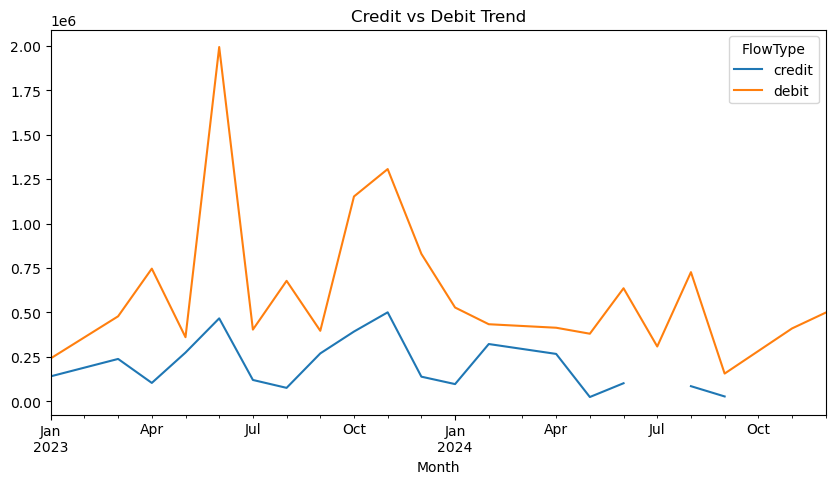

In [16]:
summary[['credit', 'debit']].plot(figsize=(10, 5))
plt.title("Credit vs Debit Trend")
plt.show()

In [17]:
net_flow = df.groupby('AccountID')['TransactionAmount'].sum()

top_account = net_flow.sort_values(ascending=False).head(5)
bottom_account = net_flow.sort_values(ascending=True).head(5)

print("Top 5 account")
print(top_account)
print("\nBottom 5 account")
print(bottom_account)

Top 5 account
AccountID
ACC61926    513514.65869
ACC64022    381600.16091
ACC99549    314327.40515
ACC16664    311043.50197
ACC57700    291477.00649
Name: TransactionAmount, dtype: float64

Bottom 5 account
AccountID
ACC26026    -4928.155336
ACC22255     4284.251081
ACC12334     9176.203157
ACC10996    17518.036520
ACC70741    17814.871250
Name: TransactionAmount, dtype: float64


In [18]:
df = df.sort_values(['AccountID', 'TransactionDate'])
df['Gap'] = df.groupby('AccountID')['TransactionDate'].diff().dt.days

dormat = df[df['Gap'] > 60]
dormat

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,FlowType,Year,Month,Gap
753,66,CUST6028,ACC10117,loan,withdrawal,Home Loan,Firm A,East,Manager 2,2024-05-02,89088.280600,64499.600480,0.273698,337,194,debit,2024,2024-05,390.0
510,56,CUST3725,ACC11188,savings,transfer,Personal Loan,Firm A,West,Manager 3,2024-05-02,57375.718280,57770.989980,0.550290,359,42,debit,2024,2024-05,326.0
219,104,CUST4595,ACC11837,credit,transfer,Credit Card,Firm A,Central,Manager 4,2023-12-01,73250.284070,127269.108900,0.394421,544,232,debit,2023,2023-12,120.0
61,111,CUST7855,ACC12334,credit,deposit,Mutual Fund,Firm C,Central,Manager 2,2024-06-02,5380.233028,69226.614170,0.420379,660,174,credit,2024,2024-06,264.0
159,15,CUST6526,ACC13357,loan,payment,Home Loan,Firm D,Central,Manager 2,2024-06-02,37884.299840,73458.518280,0.035320,373,71,debit,2024,2024-06,237.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,1,CUST2942,ACC95774,credit,transfer,Credit Card,Firm B,South,Manager 4,2024-08-02,44945.669400,117464.725700,0.421672,781,41,debit,2024,2024-08,304.0
113,84,CUST5500,ACC96868,savings,payment,Savings Account,Firm E,East,Manager 2,2024-11-06,100669.087700,96967.332940,-0.049693,582,64,debit,2024,2024-11,155.0
518,50,CUST4625,ACC99549,credit,transfer,Personal Loan,Firm E,North,Manager 3,2023-06-06,72499.162520,105166.597500,0.486469,360,50,debit,2023,2023-06,62.0
597,84,CUST7028,ACC99549,current,transfer,Mutual Fund,Firm B,West,Manager 3,2023-12-02,27349.311400,261.171238,0.401315,499,85,debit,2023,2023-12,179.0


## Task 3


In [19]:
txn_freq = df.groupby('AccountID').size()
txn_freq

AccountID
ACC10117    2
ACC10996    1
ACC11062    1
ACC11188    2
ACC11285    1
           ..
ACC95774    3
ACC96277    1
ACC96868    2
ACC97411    1
ACC99549    5
Length: 144, dtype: int64

In [20]:
def activity_level(x):
    if x > 6:
        return "High"
    elif x > 4:
        return "Medium"
    else:
        return "Low"

In [21]:
profile = txn_freq.apply(activity_level)
profile

AccountID
ACC10117       Low
ACC10996       Low
ACC11062       Low
ACC11188       Low
ACC11285       Low
             ...  
ACC95774       Low
ACC96277       Low
ACC96868       Low
ACC97411       Low
ACC99549    Medium
Length: 144, dtype: object

In [22]:
avg_balance = df.groupby('AccountID')['AccountBalance'].mean()
avg_balance

AccountID
ACC10117    82236.165250
ACC10996    82155.780970
ACC11062    35136.521340
ACC11188    51359.039950
ACC11285    94529.506640
                ...     
ACC95774    87301.204420
ACC96277    61659.158940
ACC96868    69744.612985
ACC97411    72015.805920
ACC99549    70546.745042
Name: AccountBalance, Length: 144, dtype: float64

In [23]:
transaction_volume = df.groupby('AccountID')['TransactionAmount'].sum()
transaction_volume

AccountID
ACC10117     70735.12413
ACC10996     17518.03652
ACC11062     73480.16656
ACC11188    127634.92588
ACC11285     32047.98461
                ...     
ACC95774    207673.09009
ACC96277     74309.49713
ACC96868    190696.51926
ACC97411     85935.73390
ACC99549    314327.40515
Name: TransactionAmount, Length: 144, dtype: float64

In [24]:
high_inflow = transaction_volume[transaction_volume > transaction_volume.quantile(0.75)]
print(high_inflow)
low_balance_accounts = avg_balance[avg_balance < avg_balance.quantile(0.25)].index
high_freq_accounts = txn_freq[txn_freq > txn_freq.quantile(0.75)].index
target_accounts = low_balance_accounts.intersection(high_freq_accounts)

low_balance_high_freq = df[df['AccountID'].isin(target_accounts)]
#print(low_balance_high_freq)
negative_balance = avg_balance[avg_balance <= 0]
print("negative_balance")
print(negative_balance)

AccountID
ACC15671    204724.411070
ACC16664    311043.501970
ACC17688    186118.228130
ACC18140    184948.142520
ACC19156    189629.116790
ACC20297    201159.027600
ACC21264    171019.868130
ACC24508    227840.331350
ACC28292    188998.263270
ACC29396    167137.920430
ACC32212    262484.690214
ACC34431    276714.453640
ACC38559    191259.034580
ACC41829    248184.586550
ACC45907    166812.299400
ACC45968    252111.786050
ACC46953    247292.888320
ACC48303    179155.370850
ACC48501    167905.009190
ACC57516    183042.879900
ACC57700    291477.006490
ACC58667    171989.109460
ACC60432    192919.468070
ACC61926    513514.658690
ACC64022    381600.160910
ACC71426    168980.885910
ACC72197    284108.981130
ACC73104    278503.008220
ACC78589    186719.757580
ACC82381    247236.466540
ACC88252    185335.644210
ACC94907    231006.237970
ACC95164    199856.024210
ACC95774    207673.090090
ACC96868    190696.519260
ACC99549    314327.405150
Name: TransactionAmount, dtype: float64
negative_balan

## Task 4


In [25]:
large_withdrawals = df[
    (df['FlowType'] == "debit") &
    (df['TransactionAmount'] > df['TransactionAmount'].quantile(0.95))
]
large_withdrawals


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,FlowType,Year,Month,Gap
64,161,CUST5500,ACC24508,current,transfer,Credit Card,Firm E,South,Manager 2,2023-04-02,110505.9914,68219.311590,0.685182,696,81,debit,2023,2023-04,NaN
750,24,CUST3041,ACC32212,credit,transfer,Personal Loan,Firm E,West,Manager 4,2024-06-02,106983.3477,72486.833050,0.282850,570,210,debit,2024,2024-06,61.0
115,15,CUST6549,ACC34431,current,withdrawal,Home Loan,Firm D,East,Manager 1,2023-12-05,113664.3735,99260.536620,0.153778,379,201,debit,2023,2023-12,84.0
196,165,CUST1840,ACC40939,loan,payment,Savings Account,Firm C,North,Manager 4,2024-07-06,123890.0709,91614.455500,0.240281,597,22,debit,2024,2024-07,NaN
23,158,CUST2699,ACC42467,credit,transfer,Mutual Fund,Firm B,East,Manager 3,2024-05-02,118633.9728,108732.121300,0.536264,456,81,debit,2024,2024-05,NaN
647,35,CUST7028,ACC53466,credit,withdrawal,Mutual Fund,Firm D,Central,Manager 4,2024-02-03,122296.2173,46961.935710,0.569805,669,122,debit,2024,2024-02,118.0
707,100,CUST5664,ACC57516,loan,withdrawal,Personal Loan,Firm D,West,Manager 4,2024-06-02,109874.6786,103663.958100,0.632459,394,160,debit,2024,2024-06,58.0
281,78,CUST1376,ACC58667,savings,payment,Credit Card,Firm D,North,Manager 2,2024-06-02,122025.3537,74922.334210,0.621840,828,6,debit,2024,2024-06,264.0
621,145,CUST8529,ACC61926,loan,payment,Credit Card,Firm C,East,Manager 2,2023-06-11,105628.8804,95036.203510,0.081180,658,211,debit,2023,2023-06,2.0
410,22,CUST3609,ACC61926,current,transfer,Home Loan,Firm D,North,Manager 2,2024-08-06,118787.3460,33833.613300,0.188271,472,203,debit,2024,2024-08,218.0


In [26]:

print("Overdraft_accounts")
overdraft_accounts = df[df['AccountBalance'] < 0]['AccountID']
overdraft_accounts

Overdraft_accounts


507    ACC19156
416    ACC32212
253    ACC34431
398    ACC60432
488    ACC75675
401    ACC77773
580    ACC78589
237    ACC89098
Name: AccountID, dtype: object

In [27]:
volatility = df.groupby('AccountID')['AccountBalance'].std()
volatility


AccountID
ACC10117    25083.290448
ACC10996             NaN
ACC11062             NaN
ACC11188     9067.866694
ACC11285             NaN
                ...     
ACC95774    29004.078176
ACC96277             NaN
ACC96868    38498.739765
ACC97411             NaN
ACC99549    47549.006343
Name: AccountBalance, Length: 144, dtype: float64

In [28]:
from scipy.stats import zscore

df['Amount_Zscore'] = zscore(df['TransactionAmount'])

zscore_anomalies = df[abs(df['Amount_Zscore']) > 3]
zscore_anomalies

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,FlowType,Year,Month,Gap,Amount_Zscore
161,52,CUST4258,ACC35419,loan,transfer,Personal Loan,Firm B,Central,Manager 1,2023-07-11,-36173.69555,24563.76881,0.838911,745,29,debit,2023,2023-07,34.0,-3.2475


In [29]:

suspicious_accounts = pd.concat([
    large_withdrawals['AccountID'],
    overdraft_accounts,
    zscore_anomalies['AccountID'],
    
]).dropna().unique()

suspicious_accounts

array(['ACC24508', 'ACC32212', 'ACC34431', 'ACC40939', 'ACC42467',
       'ACC53466', 'ACC57516', 'ACC58667', 'ACC61926', 'ACC62446',
       'ACC64022', 'ACC89098', 'ACC95774', 'ACC19156', 'ACC60432',
       'ACC75675', 'ACC77773', 'ACC78589', 'ACC35419'], dtype=object)

## Task5

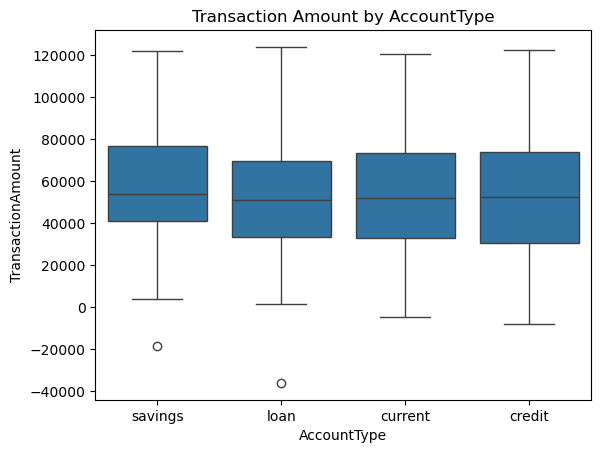

In [30]:
sns.boxplot(x='AccountType', y='TransactionAmount', data=df)
plt.title("Transaction Amount by AccountType")
plt.show()


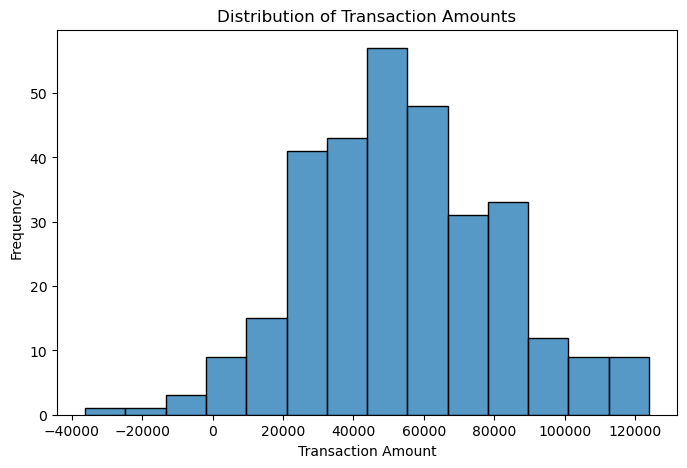

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df['TransactionAmount'])
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

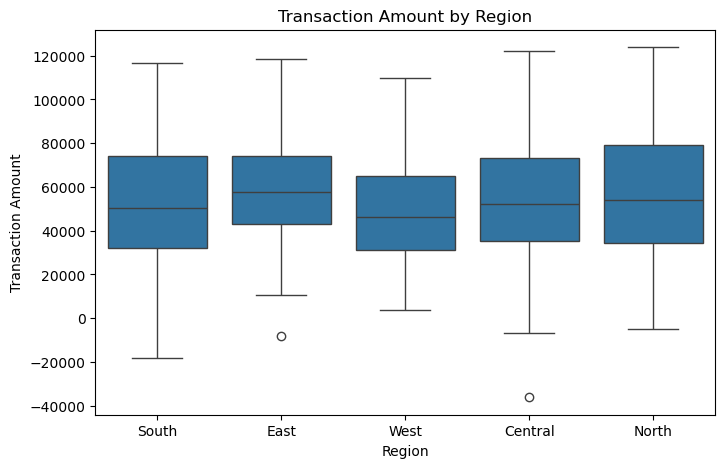

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Region', y='TransactionAmount', data=df)
plt.title("Transaction Amount by Region")
plt.xlabel("Region")
plt.ylabel("Transaction Amount")
plt.show()

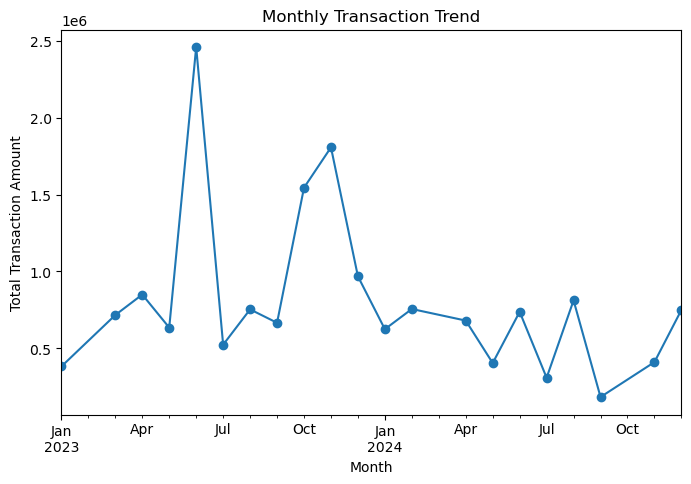

In [33]:
monthly_transactions = df.groupby('Month')['TransactionAmount'].sum()

plt.figure(figsize=(8,5))
monthly_transactions.plot(kind='line', marker='o')
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Total Transaction Amount")
plt.show()

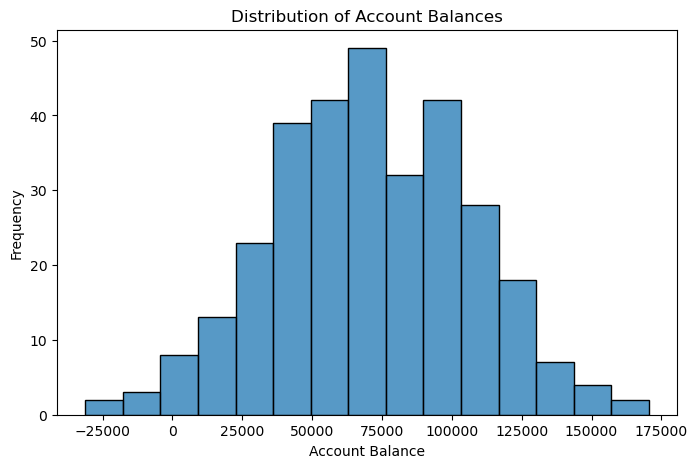

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df['AccountBalance'])
plt.title("Distribution of Account Balances")
plt.xlabel("Account Balance")
plt.ylabel("Frequency")
plt.show()

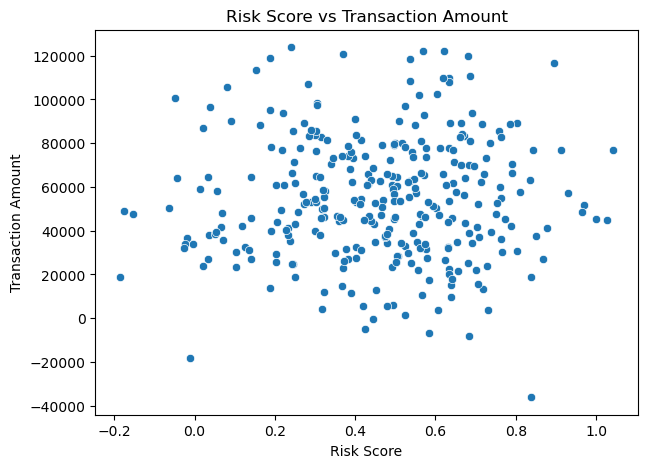

In [38]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='RiskScore', y='TransactionAmount', data=df)
plt.title("Risk Score vs Transaction Amount")
plt.xlabel("Risk Score")
plt.ylabel("Transaction Amount")
plt.show()

## Task 6

In [51]:
transactionVolume = df.groupby('AccountID')['TransactionAmount'].sum()
#transactionVolume

AvgBallance = df.groupby('AccountID')['AccountBalance'].mean()
#AvgBallance

MedianVolume = transactionVolume.median()
HighVolumeAccount =  transactionVolume[transactionVolume > MedianVolume]
LowVolumeAccount =  transactionVolume[transactionVolume <= MedianVolume]

HighBalance = AvgBallance.loc[HighVolumeAccount.index]
LowBalance = AvgBallance.loc[LowVolumeAccount.index]

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(HighBalance, LowBalance, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.04324532013194935
P-value: 0.9655723201539553
